## SECOND LABORATORY 09/09/2026
Machine Learning Pipeline

IMPORT LIBRARIES

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import f_classif

#LOAD AND UNDERSTAND THE DATASETS

In [98]:
#convert to dataframe
df = pd.read_csv("UCI_Wine_Dataset_178.csv")

In [101]:
df.head(150)

,class,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,OD280_OD315_of_diluted_wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,3,13.16,3.57,2.15,21.0,102,1.50,0.55,0.43,1.30,4.00,0.60,1.68,830
146,3,13.88,5.04,2.23,20.0,80,0.98,0.34,0.40,0.68,4.90,0.58,1.33,415
147,3,12.87,4.61,2.48,21.5,86,1.70,0.65,0.47,0.86,7.65,0.54,1.86,625
148,3,13.32,3.24,2.38,21.5,92,1.93,0.76,0.45,1.25,8.42,0.55,1.62,650


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   class                         178 non-null    int64  
 1   Alcohol                       178 non-null    float64
 2   Malicacid                     178 non-null    float64
 3   Ash                           178 non-null    float64
 4   Alcalinity_of_ash             178 non-null    float64
 5   Magnesium                     178 non-null    int64  
 6   Total_phenols                 178 non-null    float64
 7   Flavanoids                    178 non-null    float64
 8   Nonflavanoid_phenols          178 non-null    float64
 9   Proanthocyanins               178 non-null    float64
 10  Color_intensity               178 non-null    float64
 11  Hue                           178 non-null    float64
 12  OD280_OD315_of_diluted_wines  178 non-null    float64
 13  Proli

In [87]:
df.describe()

,class,Alcohol,Malicacid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,OD280_OD315_of_diluted_wines,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [100]:
df.drop(columns="ID", inplace=True)

In [115]:
df['class'].value_counts()

,count
class,
2,71
1,59
3,48


#Visualize the dataset

#Histogram

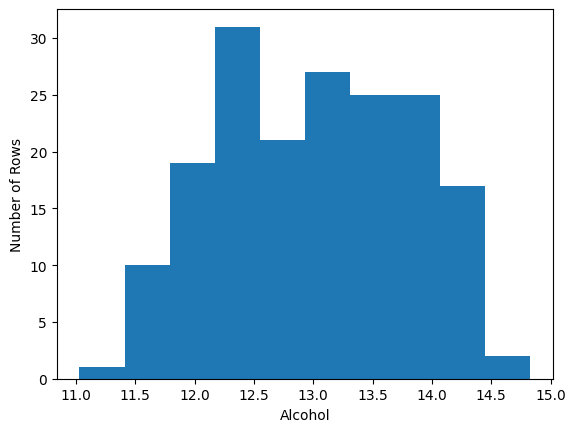

In [41]:
plt.hist(df['Alcohol'])
plt.xlabel("Alcohol")
plt.ylabel("Number of Rows")
plt.show()

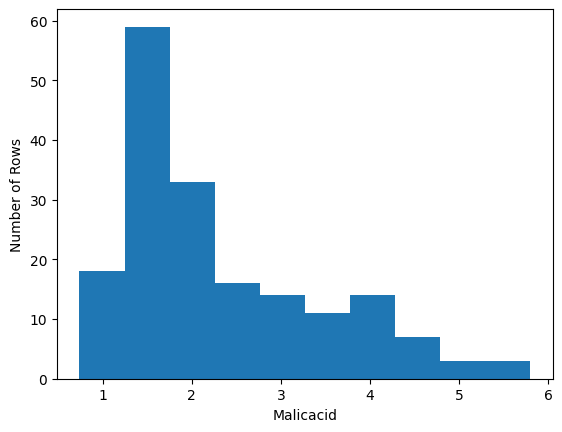

In [17]:
plt.hist(df['Malicacid'])
plt.xlabel("Malicacid")
plt.ylabel("Number of Rows")
plt.show()

#Scatter Plot

In [51]:
colors = {1: 'red',
          2: 'blue',
          3: 'green'}

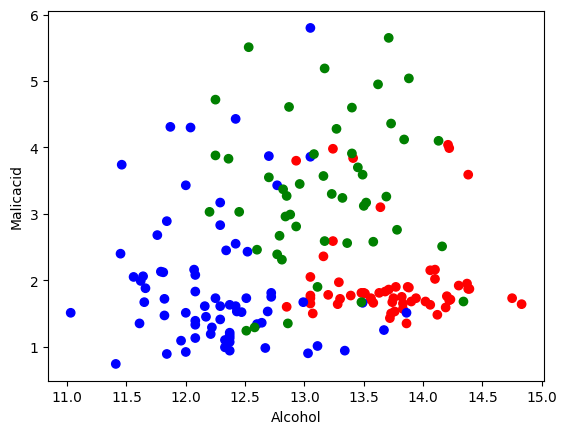

In [79]:
plt.scatter(df['Alcohol'], df['Malicacid'], c=df['class'].map(colors))
plt.xlabel("Alcohol")
plt.ylabel("Malicacid")
plt.show()

#Split the Dataset into a training set and testing set

In [104]:

X = df.drop("class", axis=1)

y = df["class"].values

In [105]:
F,p = f_classif(X,y)

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "F-Score": F,
    "P-Value": p
})

feature_scores = feature_scores.sort_values(by="F-Score", ascending=False)
feature_scores

,Feature,F-Score,P-Value
6,Flavanoids,233.925873,3.598586e-50
12,Proline,207.920374,5.783168e-47
11,OD280_OD315_of_diluted_wines,189.972321,1.393105e-44
0,Alcohol,135.077624,3.319504e-36
9,Color_intensity,120.664018,1.162008e-33
10,Hue,101.316795,5.917662e-30
5,Total_phenols,93.733010,2.137670e-28
1,Malicacid,36.943425,4.127229e-14
3,Alcalinity_of_ash,35.771637,9.444473e-14
8,Proanthocyanins,30.271383,5.125359e-12


In [106]:
top_features = feature_scores.head(5)

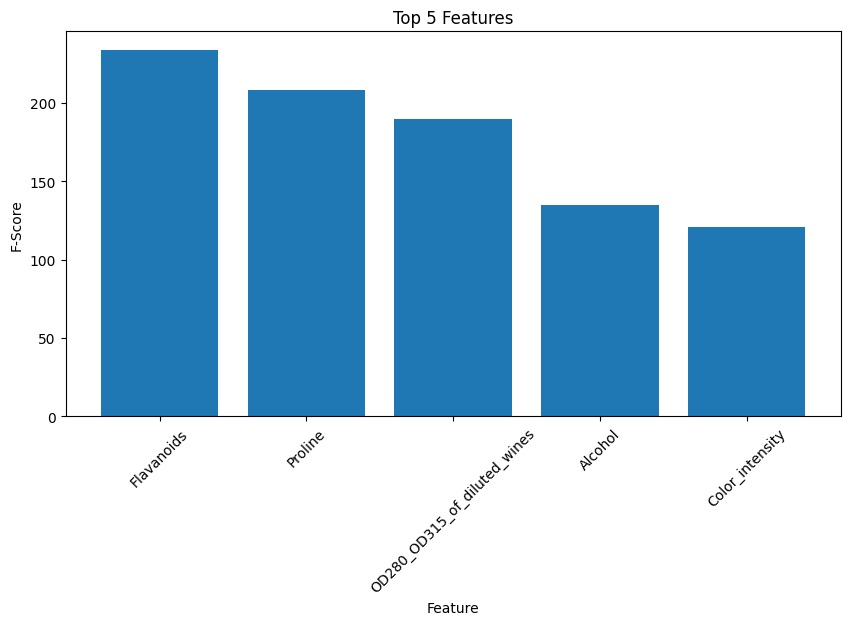

In [107]:
plt.figure(figsize=(10,5))

plt.bar(
    top_features["Feature"],
    top_features["F-Score"]
)

plt.xticks(rotation=45)
plt.xlabel("Feature")
plt.ylabel("F-Score")
plt.title("Top 5 Features")
plt.show()

In [108]:
#features
x = df.drop(columns=["class"]).values

#labels
y = df["class"].values

In [121]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=5)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(142, 13)
(36, 13)
(142,)
(36,)


In [122]:
print(x_train)

[[1.374e+01 1.670e+00 2.250e+00 ... 9.200e-01 3.200e+00 1.060e+03]
 [1.293e+01 2.810e+00 2.700e+00 ... 7.700e-01 2.310e+00 6.000e+02]
 [1.332e+01 3.240e+00 2.380e+00 ... 5.500e-01 1.620e+00 6.500e+02]
 ...
 [1.225e+01 3.880e+00 2.200e+00 ... 6.500e-01 2.000e+00 8.550e+02]
 [1.277e+01 3.430e+00 1.980e+00 ... 7.000e-01 2.120e+00 3.720e+02]
 [1.229e+01 3.170e+00 2.210e+00 ... 1.420e+00 2.830e+00 4.060e+02]]


# Create the Model

#Choose machine learning Algorithm

In [123]:
knn = KNeighborsClassifier(n_neighbors=27)

In [124]:
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=27)

#Test the Model

In [126]:


y_pred = knn.predict(x_test)

# Accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

# Precision
precision = metrics.precision_score(y_test, y_pred, average='weighted')
print('\nPrecision:', precision)

# Recall
recall = metrics.recall_score(y_test, y_pred, average='weighted')
print('\nRecall:', recall)

# F1-Score
f1 = metrics.f1_score(y_test, y_pred, average='weighted')
print('\nF1-Score:', f1)

Accuracy: 0.7222222222222222

Precision: 0.8214285714285714

Recall: 0.7222222222222222

F1-Score: 0.7294258205074144


#Display the confusion matrix

In [128]:
metrics.confusion_matrix(y_test, y_pred)

array([[12,  0,  5],
       [ 2,  6,  3],
       [ 0,  0,  8]])

#Test the Model(Prediction)

In [127]:
knn.predict([[1.24,3.22,3.52,7.22,5.25,3.62,7.25,9.22,9.61,11.23,11.93,15.22,13.62]])

array([2])